In [ ]:
# Disease Outbreak Forecasting Using ARIMA & Linear Regression
#submitted by:
#Batool Zehra(20241-35829)
#Rabia Sultan(20241-37153)

#This project analyzes global COVID-19 confirmed cases to build a time-series forecasting model using ARIMA and a baseline Linear Regression model.

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
## 1. Data Loading & Preprocessing

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CONVENIENT_global_confirmed_cases.csv to CONVENIENT_global_confirmed_cases (1).csv


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'CONVENIENT_global_confirmed_cases.csv', 'CONVENIENT_global_confirmed_cases (1).csv', 'sample_data']


In [ ]:
df = pd.read_csv("CONVENIENT_global_confirmed_cases.csv")

In [ ]:
df.head()

,Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
0,Province/State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/23/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1/24/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/25/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/26/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df.iloc[1:]

In [ ]:
df.rename(columns={'Country/Region': 'Date'}, inplace=True);

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')


In [ ]:
df.set_index('Date', inplace=True)


In [ ]:
df.head()


,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2020-01-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df.astype(float)


In [ ]:
df['Global_Cases'] = df.sum(axis=1)


In [ ]:
global_series = df['Global_Cases']


In [ ]:
print(global_series.head())


Date
2020-01-23    100.0
2020-01-24    287.0
2020-01-25    493.0
2020-01-26    683.0
2020-01-27    809.0
Name: Global_Cases, dtype: float64


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
## 2. Exploratory Data Analysis

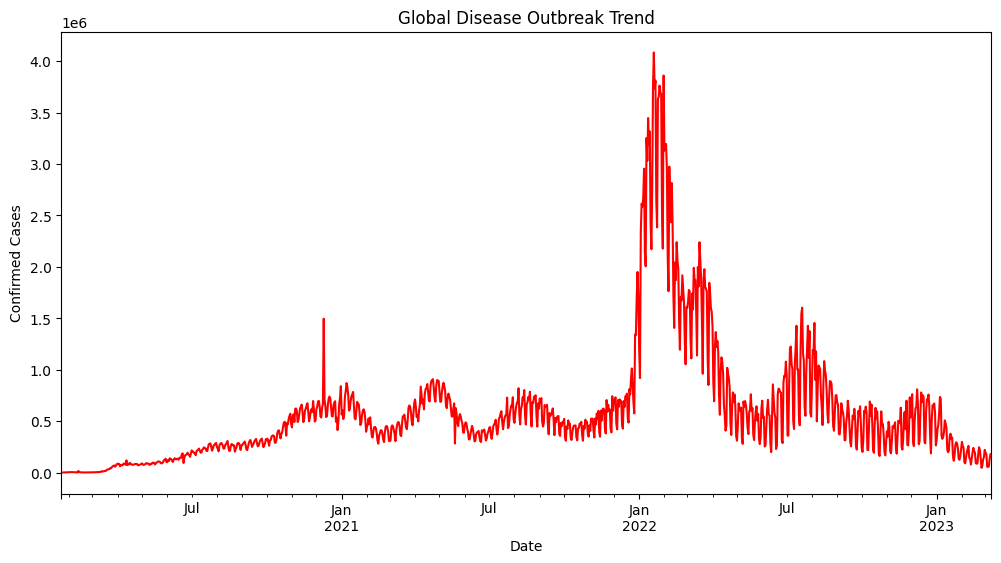

In [ ]:
global_series.plot(title="Global Disease Outbreak Trend", figsize=(12, 6), color='red')
plt.ylabel("Confirmed Cases")
plt.show()

In [ ]:
## Stationarity Testing
##We use the Augmented Dickey Fuller (ADF) test to determine whether the time series is stationary before fitting an ARIMA model.

from statsmodels.tsa.stattools import adfuller


In [ ]:
result = adfuller(global_series)


In [ ]:
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.044629
p-value: 0.030932


In [ ]:

p_value = result[1]


In [ ]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
# Taking first difference to remove trend and make the data more stationary
stationary_series = global_series.diff().dropna()


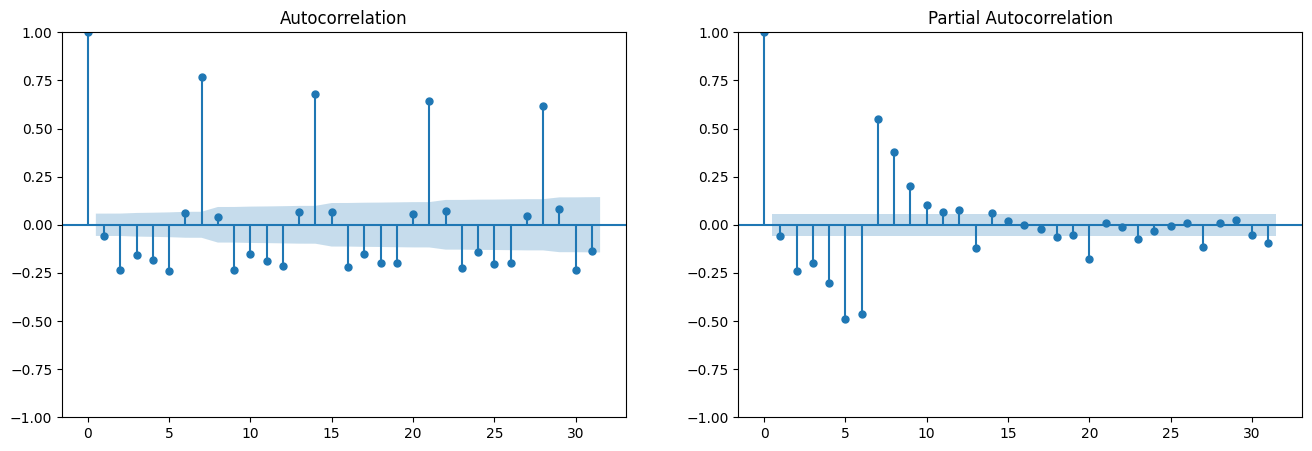

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF plot helps us estimate the MA(q) part of ARIMA
plot_acf(stationary_series, ax=axes[0])

# PACF plot helps us estimate the AR(p) part of ARIMA
plot_pacf(stationary_series, ax=axes[1])

plt.show()


In [ ]:
## 3. Model Building — ARIMA(7,1,1)

In [ ]:
global_series.index = pd.DatetimeIndex(global_series.index, freq='D')

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Building ARIMA model using parameters selected from ACF and PACF analysis

model = ARIMA(global_series, order=(7, 1, 1))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
## 4. Model Evaluation

In [ ]:
##After applying first-order differencing, the ADF test confirmed that the time series became stationary. The PACF plot showed significant spikes extending up to approximately lag 7, suggesting an autoregressive order of p=7. The ACF plot indicated a significant spike at lag 1, suggesting a moving average order of q=1. Therefore, ARIMA(7,1,1) was selected for forecasting.

In [ ]:
# We aree training the ARIMA model on historical outbreak data
model_fit = model.fit()


In [ ]:
# We evaluate forecast performance using the last 30 observations as test data
from sklearn.metrics import mean_absolute_error
train = global_series[:-30]
test = global_series[-30:]

eval_model = ARIMA(train, order=(7,1,1))
eval_fit = eval_model.fit()

predictions = eval_fit.forecast(steps=30)

# Lower MAE and RMSE values indicate better forecasting performance

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(np.mean((test - predictions)**2))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 19103.9
RMSE: 23669.94


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


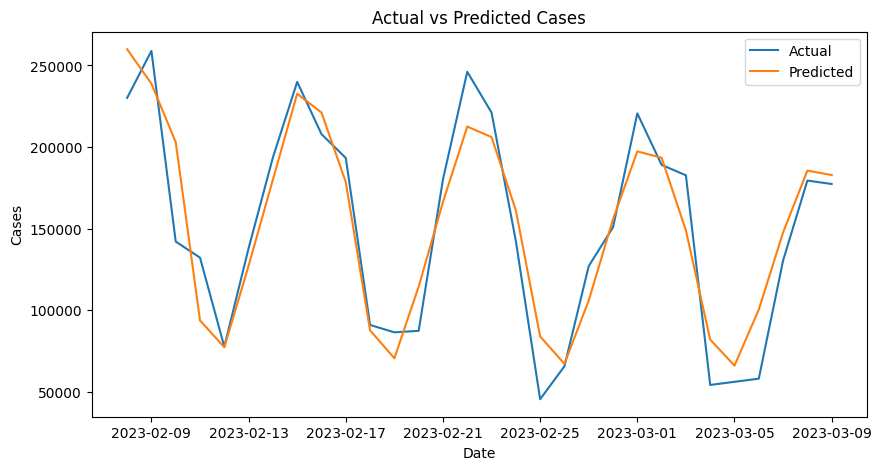

In [ ]:
# Comparing actual values with model predictions

plt.figure(figsize=(10,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")

plt.title("Actual vs Predicted Cases")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.legend()

plt.show()

In [ ]:
## 5. 14-Day Forecast

In [ ]:
# Predicting future outbreak cases for the next 14 days
forecast_steps = 14
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean

In [ ]:
forecast_ci = forecast.conf_int()

In [ ]:
print("Projected Case Counts for the next 14 days:")
print(forecast_values)

Projected Case Counts for the next 14 days:
2023-03-10    150135.129659
2023-03-11     49253.605518
2023-03-12     38530.930703
2023-03-13     49367.158419
2023-03-14    111447.647444
2023-03-15    158059.681801
2023-03-16    160062.838526
2023-03-17    127432.306733
2023-03-18     45152.519539
2023-03-19     28239.594563
2023-03-20     43163.939303
2023-03-21     97871.582272
2023-03-22    141785.532391
2023-03-23    145731.654227
Freq: D, Name: predicted_mean, dtype: float64


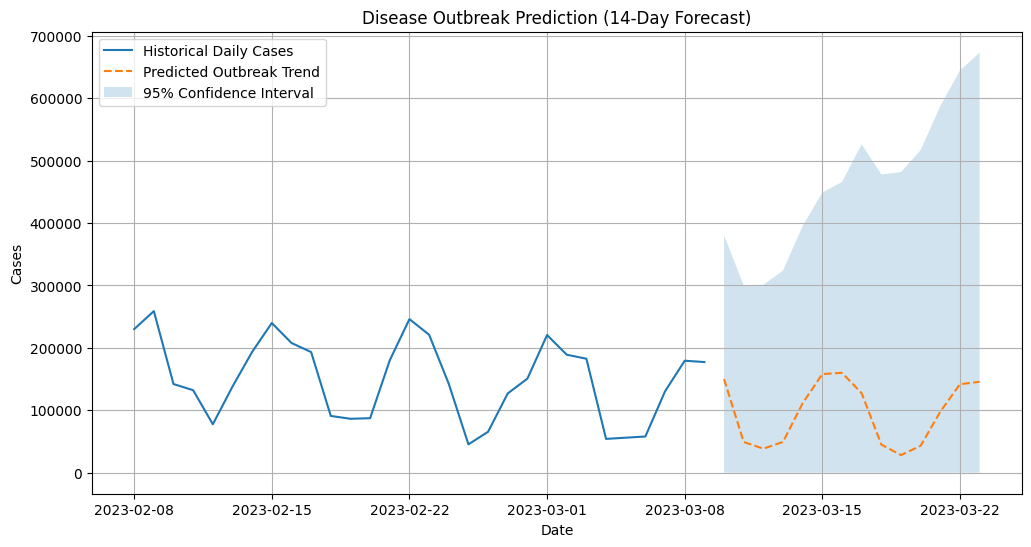

In [ ]:
# Plotting the last 30 days of real data and the 14 day forecast
# Plotting the last 30 days of real data and the 14 day forecast
future_dates = pd.date_range(
    start=global_series.index[-1] + pd.Timedelta(days=1),
    periods=14,
    freq='D'
)

# Confidence interval bounds
lower = forecast_ci.iloc[:, 0].astype(float).clip(lower=0).values
upper = forecast_ci.iloc[:, 1].astype(float).values

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    global_series.tail(30),
    label='Historical Daily Cases'
)

plt.plot(
    future_dates,
    forecast_values,
    label='Predicted Outbreak Trend',
    linestyle='--'
)

plt.fill_between(
    future_dates,
    lower,
    upper,
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("Disease Outbreak Prediction (14-Day Forecast)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The historical daily outbreak data exhibited a strong weekly cycle. The ARIMA(7,1,1) model captured this temporal dependency through the 7-lag autoregressive component. As a result, the forecast extends the recurring weekly pattern observed in the training data.

In [ ]:
import joblib


In [ ]:
joblib.dump(model_fit, 'arimaoutbreak_model.pkl')


['arimaoutbreak_model.pkl']

In [ ]:
print("Success: Your model is now saved and ready for deployment!")


Success: Your model is now saved and ready for deployment!


In [ ]:
from google.colab import files
files.download('arima_outbreak_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Saving dependencies so the project can be reproduced in any environment

!pip freeze > requirements.txt
print('requirements.txt has been generated.')

requirements.txt has been generated.


In [ ]:
## 6. Linear Regression Model

In [ ]:

ml_data = pd.DataFrame(global_series)
ml_data.columns = ['Today_Cases']


ml_data['Yesterday_Cases'] = ml_data['Today_Cases'].shift(1)


ml_data.dropna(inplace=True)

X = ml_data[['Yesterday_Cases']] # Feature
y = ml_data['Today_Cases']      # Target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:

ml_model = LinearRegression()
ml_model.fit(X_train, y_train)


y_pred = ml_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: 30255999342.722622
R-squared Score: 0.6079622189255698


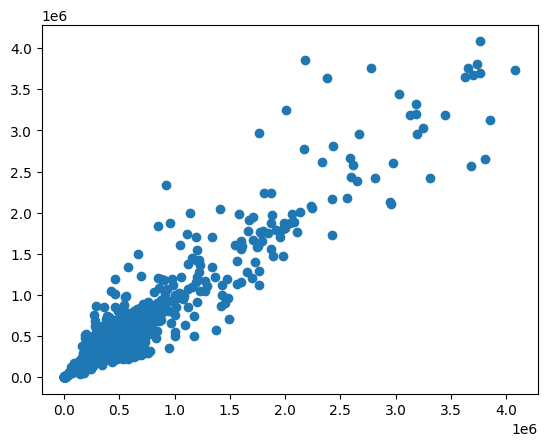

In [ ]:
# Visualizing the linear relationship between yesterday's and today's cases

plt.scatter(ml_data['Yesterday_Cases'], ml_data['Today_Cases'])

<Axes: >

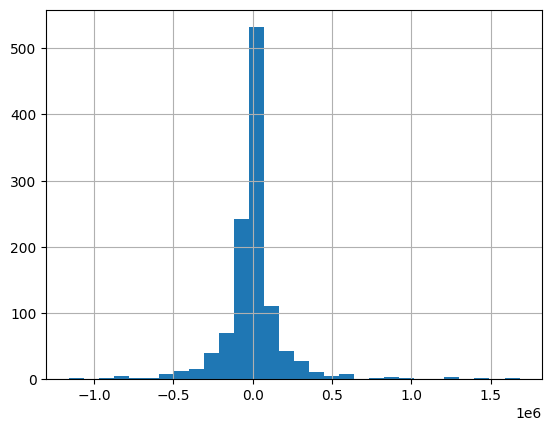

In [ ]:
# Distribution of daily changes in global cases after first differencing
global_series.diff().hist(bins=30)


<Axes: >

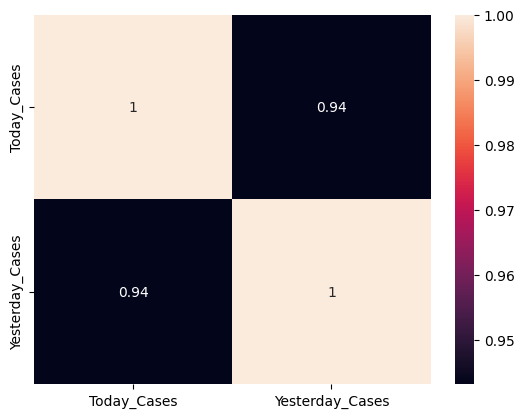

In [ ]:
# Correlation between features.High correlation confirms Yesterday_Cases is a strong predictor
import seaborn as sns
sns.heatmap(ml_data.corr(), annot=True)

In [ ]:
## 8. Conclusion
##The ARIMA(7,1,1) model achieved an MAE of 19103.9 and RMSE of 23669.94 on the 30-day test set.
##ARIMA outperformed the baseline, confirming that temporal dependencies in outbreak data are better captured by time-series models.